# Local Gaussian Forces

This notebook checks the diagnostic Hellmann-Feynman-style force for the toy local Gaussian pseudopotential. The density is held fixed for the finite-difference comparison, which isolates the derivative of the local potential energy.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from mlx_atomistic.dft import RealSpaceGrid, LocalGaussianPseudopotential, local_pseudopotential_forces

The density peak is shifted to the right of the pseudopotential center, so the center should feel a positive x-direction force.

In [3]:
grid = RealSpaceGrid((16, 16, 16), [6.0, 6.0, 6.0])
coordinates = np.array(grid.coordinates())
density = np.exp(-np.sum((coordinates - np.array([3.6, 3.0, 3.0])) ** 2, axis=-1) / 0.7).astype(np.float32)
density *= 2.0 / (np.sum(density) * grid.dv)

pseudopotential = LocalGaussianPseudopotential([[3.0, 3.0, 3.0]], -2.0, 0.8)
force = np.array(local_pseudopotential_forces(density, grid, pseudopotential))[0]
force

array([ 1.0506039e+00,  1.2572855e-08, -8.1445979e-09], dtype=float32)

For the finite-difference curve, only the center coordinate moves. The slope of the local energy curve is `-force`.

In [4]:
def local_energy(center_x):
    shifted = LocalGaussianPseudopotential([[center_x, 3.0, 3.0]], -2.0, 0.8)
    return float(np.sum(density * np.array(shifted.field(grid))) * grid.dv)

center_values = np.linspace(2.85, 3.15, 21)
energies = [local_energy(center) for center in center_values]
epsilon = 1e-3
finite_difference_force = -(local_energy(3.0 + epsilon) - local_energy(3.0 - epsilon)) / (2.0 * epsilon)

{"analytic_force_x": float(force[0]), "finite_difference_force_x": finite_difference_force}

{'analytic_force_x': 1.0506038665771484,
 'finite_difference_force_x': 1.050710678100586}

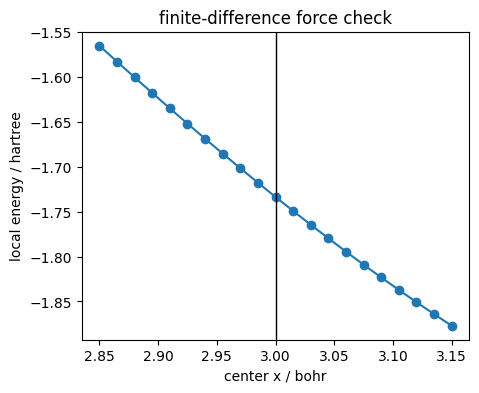

In [5]:
plt.figure(figsize=(5, 4))
plt.plot(center_values, energies, marker="o")
plt.axvline(3.0, color="black", linewidth=1)
plt.xlabel("center x / bohr")
plt.ylabel("local energy / hartree")
plt.title("finite-difference force check");